In [84]:
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchmetrics as tm

In [83]:
root_path = "/home/stefan/ioai-prep/kits/subconscious"
device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 42
torch.random.manual_seed(seed)

batch_size = 32

# Data

In [136]:
train_df = pd.read_csv(f"{root_path}/train.csv")
test_df = pd.read_csv(f"{root_path}/test.csv")

train_df["Holograma_Matrix"] = train_df["Holograma_Matrix"].apply(eval)
test_df["Holograma_Matrix"] = test_df["Holograma_Matrix"].apply(eval)

train_df.head()

,ID,Text_Oniric,Holograma_Matrix,Eticheta_Contextuala_Simbolica,Interconectare_Simbolica_Target
0,MNE_93810,ιφσηηφθσδδφιιθιλθιθηησιθλκιδσλλθσηηθθκφη,"[0.14967141530112327, 0.08617356988288154, 0.1...",Void,The empty abyssal region is seen as it dissolv...
1,MNE_24592,ξσδψδχθξφχξσσφφχηξφξθξσψσηψξφδχηφθφψψσχδξφθχφφ...,"[0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, ...",Grid,Observation: The rigid lattice framework colla...
2,MNE_13278,οσοθρσδρδοηησρωωοηρθοσωθδδοσηηηθδροφοθροθηθοδο...,"[0.09291631520839098, 0.10911248672533769, 0.1...",Void,The empty abyssal region stabilizes the surrou...
3,MNE_46048,οηφωσδωρηδοοηθσδ,"[0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, ...",Grid,Observation: The rigid lattice framework stabi...
4,MNE_42098,αασσσθηθαθφα,"[0.026393478145935026, 0.0, 0.1306619786981922...",Cluster,The dense node cluster expands rapidly into th...


In [284]:
train_df["Interconectare_Simbolica_Target"].value_counts()

Interconectare_Simbolica_Target
The dense node cluster stabilizes the surrounding field, thereby leaving no trace in the archives.                 24
The rigid lattice framework collapses under its own weight, thereby triggering a critical system overload.         21
The oscillating sine wave expands rapidly into the ether, thereby leaving no trace in the archives.                21
The rigid lattice framework is seen as it collapses under its own weight, causing a moderate shift in topology.    21
The dense node cluster dissolves into pure information, thereby causing a moderate shift in topology.              21
                                                                                                                   ..
The oscillating sine wave collapses under its own weight, thereby generating a faint emotional residue.             6
The empty abyssal region expands rapidly into the ether, thereby generating a faint emotional residue.              6
The oscillating sine wav

<Axes: >

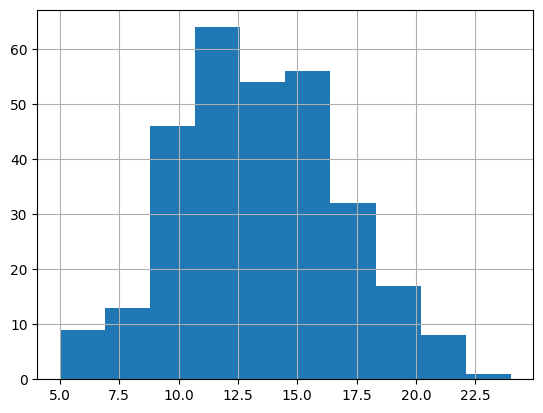

In [286]:
pd.Series(train_df["Interconectare_Simbolica_Target"].value_counts().values).hist()

In [287]:
len(train_df["Interconectare_Simbolica_Target"].value_counts().values)

300

In [288]:
len(train_df)

4000

(<Axes: >, 140, 140)

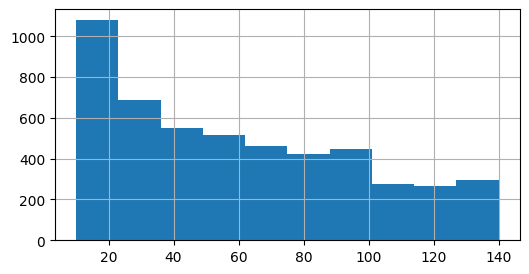

In [137]:
plt.figure(figsize=(6,3))
train_df["Text_Oniric"].apply(len).hist(), train_df["Text_Oniric"].apply(
    len
).max(), test_df["Text_Oniric"].apply(len).max()

## Tokenize

In [138]:
tokens = set()

def add_tok(s):
    for ch in list(s):
        tokens.add(ch) 

train_df["Text_Oniric"].apply(add_tok)

tokens = list(tokens)
print(tokens)

['ω', 'χ', 'δ', 'λ', 'ψ', 'σ', 'α', 'κ', 'η', 'ο', 'μ', 'θ', 'φ', 'τ', 'ρ', 'ι', 'γ', 'β', 'ν', 'ξ']


In [139]:
tok2id = {t:i for i, t in enumerate(tokens)}
id2tok = {tok2id[t]:t for t in tokens}

vocab_size = len(tokens)

print(id2tok)
vocab_size

{0: 'ω', 1: 'χ', 2: 'δ', 3: 'λ', 4: 'ψ', 5: 'σ', 6: 'α', 7: 'κ', 8: 'η', 9: 'ο', 10: 'μ', 11: 'θ', 12: 'φ', 13: 'τ', 14: 'ρ', 15: 'ι', 16: 'γ', 17: 'β', 18: 'ν', 19: 'ξ'}


20

In [140]:
def tokenize(s):
    tokens = list(s)
    tokens = [tok2id[t] for t in tokens]
    return tokens

sample_str = train_df["Text_Oniric"].iloc[0]
sample_tokens = tokenize(sample_str)
print(sample_tokens)

[15, 12, 5, 8, 8, 12, 11, 5, 2, 2, 12, 15, 15, 11, 15, 3, 11, 15, 11, 8, 8, 5, 15, 11, 3, 7, 15, 2, 5, 3, 3, 11, 5, 8, 8, 11, 11, 7, 12, 8]


In [141]:
one_hot = F.one_hot(torch.tensor(sample_tokens), num_classes=vocab_size)
one_hot.shape

torch.Size([40, 20])

## Dataset

In [142]:
class OniricDataset(Dataset):
    def __init__(self, df: pd.DataFrame, max_len: int = 140, pad_token_id: int = 0):
        super().__init__()
        self.df = df

        self.max_len = max_len
        self.pad_token_id = pad_token_id

        if "Eticheta_Contextuala_Simbolica" in df:
            self.le = LabelEncoder()
            self.df["Eticheta_Contextuala_Simbolica"] = self.le.fit_transform(
                df["Eticheta_Contextuala_Simbolica"]
            )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        tokens = torch.tensor(tokenize(row["Text_Oniric"]), dtype=torch.long)
        tokens = torch.nn.functional.pad(
            tokens, (0, self.max_len - len(tokens)), value=self.pad_token_id
        )

        # img_vals = [float(x) for x in row["Holograma_Matrix"].replace(",", " ").split()]
        img = row["Holograma_Matrix"]
        img = torch.tensor(img, dtype=torch.float32).view(64, 64)

        if "Eticheta_Contextuala_Simbolica" in row:
            label = torch.tensor(row["Eticheta_Contextuala_Simbolica"], dtype=torch.long)
            return tokens, img, label
        return tokens, img

    def __len__(self):
        return len(self.df)

In [143]:
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=seed)

train_ds = OniricDataset(train_df)
val_ds = OniricDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

test_ds = OniricDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

In [144]:
# sanity check
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([32, 140]), torch.Size([32, 64, 64]), torch.Size([32])]

In [145]:
n_classes = len(train_ds.le.classes_)
n_classes

5

# Model

In [197]:
class OniricModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        n_classes: int,
        embed_dim: int = 256,
        dropout: float = 0.3,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Multi-scale 1D convolutions for pattern extraction
        self.text_conv_3 = nn.Conv1d(embed_dim, 256, kernel_size=3, padding=1)
        self.text_conv_5 = nn.Conv1d(embed_dim, 256, kernel_size=5, padding=2)
        self.text_conv_7 = nn.Conv1d(embed_dim, 256, kernel_size=7, padding=3)

        # Image branch - CNN for 64x64 hologram
        self.img_conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.img_conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.img_conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.img_pool = nn.AdaptiveAvgPool2d(1)

        # Fusion and classification head
        self.dropout = nn.Dropout(dropout)
        # Text features: 256*3 = 768, Image features: 256
        self.fc_fusion = nn.Linear(768 + 256, 512)
        self.fc1 = nn.Linear(512, 256)
        self.fc_out = nn.Linear(256, n_classes)

    def forward(self, ids, img):
        """
        Args:
            ids: Token IDs [batch_size, seq_len]
            img: Hologram matrix [batch_size, 64, 64]
        Returns:
            logits: [batch_size, n_classes]
        """
        batch_size = ids.size(0)

        # --- Text Branch ---
        # Embed tokens: [B, L] -> [B, L, D]
        x_text = self.embedding(ids)
        # Permute for Conv1d: [B, D, L]
        x_text = x_text.permute(0, 2, 1)

        # Multi-scale feature extraction
        feat_3 = F.relu(self.text_conv_3(x_text))
        feat_5 = F.relu(self.text_conv_5(x_text))
        feat_7 = F.relu(self.text_conv_7(x_text))

        # Global max pooling: [B, 256, L] -> [B, 256]
        feat_3 = F.adaptive_max_pool1d(feat_3, 1).view(batch_size, -1)
        feat_5 = F.adaptive_max_pool1d(feat_5, 1).view(batch_size, -1)
        feat_7 = F.adaptive_max_pool1d(feat_7, 1).view(batch_size, -1)

        # Concatenate multi-scale features
        x_text = torch.cat([feat_3, feat_5, feat_7], dim=1)  # [B, 768]

        # --- Image Branch ---
        # Add channel dimension: [B, 64, 64] -> [B, 1, 64, 64]
        x_img = img.unsqueeze(1)

        x_img = F.relu(self.img_conv1(x_img))
        x_img = F.relu(self.img_conv2(x_img))
        x_img = F.relu(self.img_conv3(x_img))

        # Global pooling: [B, 256, H, W] -> [B, 256]
        x_img = self.img_pool(x_img).view(batch_size, -1)

        # --- Fusion & Classification ---
        x = torch.cat([x_text, x_img], dim=1)  # [B, 768 + 256]
        x = self.dropout(x)

        x = F.relu(self.fc_fusion(x))
        x = self.dropout(x)

        x = F.relu(self.fc1(x))
        logits = self.fc_out(x)

        return logits

In [198]:
cls_model = OniricModel(vocab_size, n_classes).to(device)
cls_model(batch[0].to(device), batch[1].to(device)).shape

torch.Size([32, 5])

# Subtask 1 training

In [199]:
lr = 2e-4
epochs = 2

optimizer = torch.optim.AdamW(cls_model.parameters(), lr)
criterion = nn.CrossEntropyLoss()
f1 = tm.F1Score(task='multiclass', num_classes=n_classes).to(device)

In [200]:
for epoch in range(1, epochs+1):
    running_loss = 0.0
    cls_model.train()
    for ids, img, label in tqdm(train_loader):
        ids, img, label = ids.to(device), img.to(device), label.to(device)

        logits = cls_model(ids, img)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    cls_model.eval()
    f1.reset()
    for ids, img, label in tqdm(val_loader):
        ids, img, label = ids.to(device), img.to(device), label.to(device)

        with torch.no_grad():
            logits = cls_model(ids, img)
        f1(logits, label)
    
    f1_metric = f1.compute()
    avg_loss = running_loss / len(train_loader)
    print(f"epoch {epoch}, loss={avg_loss:.3f}, f1={f1_metric:.3f}")

  0%|          | 0/125 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:00<00:00, 38.96it/s]


epoch 1, loss=0.921, f1=0.961


100%|██████████| 32/32 [00:00<00:00, 39.42it/s]

epoch 2, loss=0.124, f1=1.000


In [201]:
torch.save(cls_model.state_dict(), f"{root_path}/best_cls_model.pt")

# Subtask 2: Narrative Generation

## Word-level Tokenizer for Output

In [202]:
target_texts = train_df["Interconectare_Simbolica_Target"].tolist()

# Build word vocabulary
word_tokens = set()
for text in target_texts:
    word_tokens.update(text.split())

word_tokens = ["<pad>", "<sos>", "<eos>", "<unk>"] + list(word_tokens)
word2id = {w: i for i, w in enumerate(word_tokens)}
id2word = {i: w for w, i in word2id.items()}
output_vocab_size = len(word_tokens)

print(f"Output vocabulary size: {output_vocab_size}")

Output vocabulary size: 74


In [203]:
def tokenize_output(text, max_len=100):
    """Word-level tokenization with sos/eos"""
    words = text.split()[: max_len - 2]  # Reserve space for sos/eos
    tokens = [word2id["<sos>"]]
    tokens += [word2id.get(w, word2id["<unk>"]) for w in words]
    tokens.append(word2id["<eos>"])
    return torch.tensor(tokens, dtype=torch.long)


def detokenize_output(tokens):
    """Convert token IDs back to string"""
    if isinstance(tokens, torch.Tensor):
        tokens = tokens.cpu().tolist()
    words = [id2word.get(t, "<unk>") for t in tokens]
    # Remove special tokens
    words = [w for w in words if w not in ["<sos>", "<eos>", "<pad>"]]
    return " ".join(words)

In [204]:
# Test tokenization
sample_target = train_df["Interconectare_Simbolica_Target"].iloc[0]
sample_target_tokens = tokenize_output(sample_target)
print(f"Sample: {sample_target}")
print(f"Tokens: {sample_target_tokens}")
print(f"Detokenized: {detokenize_output(sample_target_tokens)}")

Sample: The oscillating sine wave stabilizes the surrounding field, thereby causing a moderate shift in topology.
Tokens: tensor([ 1, 41, 23, 69, 53, 59,  8, 21, 60, 71, 67, 26, 64, 66, 70, 29,  2])
Detokenized: The oscillating sine wave stabilizes the surrounding field, thereby causing a moderate shift in topology.


In [205]:
class OniricSeq2SeqDataset(OniricDataset):
    def __init__(
        self, df: pd.DataFrame, max_src_len: int = 140, max_tgt_len: int = 100
    ):
        super().__init__(df, max_len=max_src_len)
        self.max_tgt_len = max_tgt_len

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Source (same as before)
        tokens = torch.tensor(tokenize(row["Text_Oniric"]), dtype=torch.long)
        tokens = torch.nn.functional.pad(
            tokens, (0, self.max_len - len(tokens)), value=self.pad_token_id
        )

        img = row["Holograma_Matrix"]
        img = torch.tensor(img, dtype=torch.float32).view(64, 64)

        # Target sequence
        target = tokenize_output(
            row["Interconectare_Simbolica_Target"], self.max_tgt_len
        )

        # Pad target to max_tgt_len
        if len(target) < self.max_tgt_len:
            target = torch.nn.functional.pad(
                target, (0, self.max_tgt_len - len(target)), value=word2id["<pad>"]
            )
        else:
            target = target[: self.max_tgt_len]

        return tokens, img, target

In [206]:
train_seq_df, val_seq_df = train_test_split(train_df, test_size=0.2, random_state=seed)

train_seq_ds = OniricSeq2SeqDataset(train_seq_df)
val_seq_ds = OniricSeq2SeqDataset(val_seq_df)

train_seq_loader = DataLoader(
    train_seq_ds, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4
)
val_seq_loader = DataLoader(
    val_seq_ds, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4
)

In [207]:
# sanity check
batch_seq = next(iter(train_seq_loader))
[b.shape for b in batch_seq]

[torch.Size([32, 140]), torch.Size([32, 64, 64]), torch.Size([32, 100])]

## Seq2Seq model

In [268]:
class OniricGenerator(nn.Module):
    def __init__(
        self,
        encoder: OniricModel,
        output_vocab_size: int,
        embed_dim: int = 256,
        num_decoder_layers: int = 16,
        num_heads: int = 16,
        dropout: float = 0.3,
        max_tgt_len: int = 200,
    ):
        super().__init__()

        # Freeze encoder weights (optional, can be fine-tuned)
        self.encoder = encoder
        # Remove classification head
        self.encoder.fc_out = nn.Identity()

        # Decoder embeddings
        self.decoder_embed = nn.Embedding(
            output_vocab_size, embed_dim, padding_idx=word2id["<pad>"]
        )
        self.pos_encoding = nn.Parameter(torch.randn(1, max_tgt_len, embed_dim))

        # Transformer decoder layers with cross-attention
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.decoder = nn.TransformerDecoder(
            decoder_layer, num_layers=num_decoder_layers
        )

        # Output projection
        self.ln_out = nn.LayerNorm(embed_dim)
        self.fc_out = nn.Linear(embed_dim, output_vocab_size)

        self.dropout = nn.Dropout(dropout)
        self.max_tgt_len = max_tgt_len

    def forward(self, ids, img, target):
        """
        Args:
            ids: Source token IDs [batch_size, src_len]
            img: Hologram matrix [batch_size, 64, 64]
            target: Target token IDs [batch_size, tgt_len]
        Returns:
            logits: [batch_size, tgt_len, vocab_size]
        """
        # Encode source (text + image)
        # Get encoder features before fc_out
        memory = self.encoder(ids, img)  # [B, 512]

        # Project memory for cross-attention
        memory = memory.unsqueeze(1)  # [B, 1, 512]

        # Target embeddings with positional encoding
        tgt_embed = self.decoder_embed(target)  # [B, tgt_len, embed_dim]
        tgt_embed = tgt_embed + self.pos_encoding[:, : tgt_embed.size(1), :]
        tgt_embed = self.dropout(tgt_embed)

        # Causal mask for autoregressive decoding
        tgt_len = target.size(1)
        causal_mask = torch.triu(
            torch.ones(tgt_len, tgt_len, dtype=torch.bool), diagonal=1
        ).to(device)

        # Decode with cross-attention to encoder memory
        decoder_out = self.decoder(
            tgt_embed,
            memory,
            tgt_mask=causal_mask,
            memory_mask=None,
        )

        decoder_out = self.ln_out(decoder_out)
        logits = self.fc_out(decoder_out)  # [B, tgt_len, vocab_size]

        return logits

In [269]:
gen_model = OniricGenerator(cls_model, output_vocab_size).to(device)
# Test forward pass
test_logits = gen_model(
    batch_seq[0].to(device), batch_seq[1].to(device), batch_seq[2].to(device)
)
print(f"Logits shape: {test_logits.shape}")

Logits shape: torch.Size([32, 100, 74])


In [270]:
num = sum(p.numel() for p in gen_model.parameters())
num / 10**6 

18.959434

## Training

In [271]:
# Load pretrained encoder weights
gen_model.encoder.load_state_dict(cls_model.state_dict(), strict=False)

# Unfreeze encoder for fine-tuning (set requires_grad=False to freeze)
for param in gen_model.encoder.parameters():
    param.requires_grad = True  # Set False to freeze

lr_gen = 1e-4
epochs_gen = 30

optimizer_gen = torch.optim.AdamW(gen_model.parameters(), lr=lr_gen)
criterion_gen = nn.CrossEntropyLoss(ignore_index=word2id["<pad>"])

In [272]:
best_val_loss = float("inf")
patience = 5
patience_counter = 0

for epoch in range(1, epochs_gen + 1):
    running_loss = 0.0
    gen_model.train()

    for ids, img, target in tqdm(train_seq_loader, desc=f"Train Epoch {epoch}"):
        ids, img, target = ids.to(device), img.to(device), target.to(device)

        # Teacher forcing: feed target as input
        logits = gen_model(ids, img, target)

        # Shift target for next-token prediction
        loss = criterion_gen(
            logits[:, :-1, :].reshape(-1, output_vocab_size), target[:, 1:].reshape(-1)
        )

        optimizer_gen.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gen_model.parameters(), max_norm=1.0)
        optimizer_gen.step()

        running_loss += loss.item()

    # Validation
    val_loss = 0.0
    gen_model.eval()
    with torch.no_grad():
        for ids, img, target in tqdm(val_seq_loader, desc=f"Val Epoch {epoch}"):
            ids, img, target = ids.to(device), img.to(device), target.to(device)
            logits = gen_model(ids, img, target)
            loss = criterion_gen(
                logits[:, :-1, :].reshape(-1, output_vocab_size),
                target[:, 1:].reshape(-1),
            )
            val_loss += loss.item()

    avg_train_loss = running_loss / len(train_seq_loader)
    avg_val_loss = val_loss / len(val_seq_loader)
    print(
        f"Epoch {epoch}: train_loss={avg_train_loss:.3f}, val_loss={avg_val_loss:.3f}"
    )

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(gen_model.state_dict(), f"{root_path}/best_gen_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Val Epoch 1: 100%|██████████| 25/25 [00:01<00:00, 18.62it/s]


Epoch 1: train_loss=3.989, val_loss=3.703


Val Epoch 2: 100%|██████████| 25/25 [00:01<00:00, 19.07it/s]


Epoch 2: train_loss=3.193, val_loss=2.638


Val Epoch 3: 100%|██████████| 25/25 [00:01<00:00, 18.99it/s]


...

Epoch 28: train_loss=0.094, val_loss=0.115


Val Epoch 29: 100%|██████████| 25/25 [00:01<00:00, 19.89it/s]


Epoch 29: train_loss=0.091, val_loss=0.104


Val Epoch 30: 100%|██████████| 25/25 [00:01<00:00, 19.89it/s]

Epoch 30: train_loss=0.090, val_loss=0.104
Early stopping at epoch 30


In [273]:
# Load best model
gen_model.load_state_dict(torch.load(f"{root_path}/best_gen_model.pt"))

<All keys matched successfully>

# Submission

In [274]:
# subtask 1
cls_model = OniricModel(vocab_size, n_classes).to(device)
cls_model.load_state_dict(torch.load(f"{root_path}/best_cls_model.pt"))
cls_model.eval()
subtask1 = []

for ids, img in tqdm(test_loader):
    ids, img = ids.to(device), img.to(device)

    with torch.no_grad():
        logits = cls_model(ids, img)
    classes = torch.argmax(logits, dim=1)
    subtask1.extend(classes.cpu().tolist())

subtask1 = train_ds.le.inverse_transform(subtask1)

100%|██████████| 32/32 [00:00<00:00, 37.33it/s]


In [275]:
def generate_narrative(model, ids, img, max_len=100, temperature=0.8):
    """Greedy decoding with temperature"""
    model.eval()
    with torch.no_grad():
        # Encode source
        memory = model.encoder(ids, img).unsqueeze(1)

        # Start with <sos>
        generated = torch.full((ids.size(0), 1), word2id["<sos>"], dtype=torch.long).to(
            device
        )

        for _ in range(max_len):
            # Get decoder output
            tgt_embed = (
                model.decoder_embed(generated)
                + model.pos_encoding[:, : generated.size(1), :]
            )
            causal_mask = torch.triu(
                torch.ones(generated.size(1), generated.size(1), dtype=torch.bool),
                diagonal=1,
            ).to(device)

            out = model.decoder(tgt_embed, memory, tgt_mask=causal_mask)
            out = model.ln_out(out)
            logits = model.fc_out(out[:, -1, :])  # Only last token

            # Apply temperature
            logits = logits / temperature
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            generated = torch.cat([generated, next_token], dim=1)

            # Stop if all sequences have <eos>
            if (next_token == word2id["<eos>"]).all():
                break

        return generated

In [276]:
# subtask 2
gen_model.eval()
subtask2_predictions = []

for ids, img in tqdm(test_loader, desc="Generating narratives"):
    ids, img = ids.to(device), img.to(device)

    # Generate with batch size
    generated = generate_narrative(gen_model, ids, img, max_len=100)

    # Convert to strings
    for i in range(generated.size(0)):
        pred = detokenize_output(generated[i])
        # Ensure 30-100 words
        words = pred.split()
        if len(words) > 100:
            pred = " ".join(words[:100])
        subtask2_predictions.append(pred)

Generating narratives: 100%|██████████| 32/32 [00:08<00:00,  3.67it/s]


In [277]:
def build_subtask_df(id, answer):
    return pd.DataFrame(
        {
            "subtaskID": id,
            "datapointID": test_df["ID"],
            "answer": answer,
        },
    )


subtasks = [(1, subtask1), (2, subtask2_predictions)]

submission = pd.concat(
    [build_subtask_df(id, answer) for id, answer in subtasks], ignore_index=True
)

In [278]:
submission.head()

,subtaskID,datapointID,answer
0,1,MNE_14965,Cluster
1,1,MNE_21471,Grid
2,1,MNE_19600,Wave
3,1,MNE_33329,Cluster
4,1,MNE_43018,Void


In [279]:
submission.to_csv(f"{root_path}/submission.csv", index=False)